<a href="https://colab.research.google.com/github/komalvirk1801/PythonProjects/blob/main/YELP_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YELP DATA ANALYSIS**

#Step 1: Define Project Objectives



✅ Identify the key goals of your analysis. For example:

Understand customer preferences.
Identify top-rated restaurants.
Analyze trends in pricing, cuisine, or location.
Investigate peak operating hours for popular spots.

In [ ]:
!pip install requests pandas

!pip install imbalanced-learn


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import pandas as pd
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Step 2: Data Collection

In [ ]:


# Your Yelp API Key (replace with your actual key)
API_KEY = '5iCYzD9UIb1p4QlE1CBqqRupAttmWFi4OLzzldkCbWCfZ0vttmtuPi1lupPlB9ik1uFM63yIkv6GoV_TKksP0UYgbk268ixTXYp-j6Hf7KRAgF8ZUEpV6BmHXKjLZ3Yx'
API_URL = 'https://api.yelp.com/v3/businesses/search'

# Define headers with API key
headers = {
    'Authorization': f'Bearer {API_KEY}',
}



In [ ]:
# function to get data from YELP website based on the defined params using the API_KEY.

def fetch_yelp_data(location_name, API_URL, headers, max_results=200):
    params = {
        'term': 'restaurants',  # Searching for restaurants
        'location': location_name,  # Location name (e.g., Richmond)
        'limit': 50,  # Number of results per API call (maximum 50)
        'sort_by': 'best_match',  # Sort by rating (or other criteria)
    }

    all_results = []
    total_fetched = 0
    offset = 0  # Initialize the offset to start at the beginning

    while total_fetched < max_results:
        params['offset'] = offset  # Set the offset for the API request
        response = requests.get(API_URL, headers=headers, params=params)

        # Check if the request was successful
        if response.status_code == 200:
            data = response.json()
            businesses = data.get('businesses', [])

            # Extract relevant data from each business
            for business in businesses:
                restaurant_info = {
                    'name': business.get('name'),
                    'rating': business.get('rating'),
                    'review_count': business.get('review_count'),
                    'price': business.get('price'),
                    'cuisine': ', '.join(business.get('categories')[0]['title'] for category in business.get('categories', [])),
                    'address': ', '.join(business.get('location').get('address', [])),
                    'city': business.get('location').get('city'),
                    'state': business.get('location').get('state'),
                    'zip': business.get('location').get('zip_code'),
                    'transactions': ', '.join(business.get('transactions', [])),  # Get transaction types (e.g., delivery, pickup)
                    'latitude': business.get('coordinates').get('latitude'),
                    'longitude': business.get('coordinates').get('longitude')


                }
                all_results.append(restaurant_info)

            total_fetched += len(businesses)  # Increment the count of fetched businesses
            offset += 50  # Increment the offset to fetch the next set of results

            print(f"Fetched {total_fetched} businesses so far...")

        else:
            # If the API request fails, print the error message
            print(f"Error: {response.status_code}")
            print(response.json())  # Print the error message from the API
            break

    return all_results



In [ ]:
# Fetch up to 200 restaurant records
vancouver_restaurant_data = fetch_yelp_data('Vancouver',API_URL, headers, max_results= 200)

# Convert the data to a DataFrame for further analysis or storage
vancouver_restaurant_df = pd.DataFrame(vancouver_restaurant_data)

# Show the first few rows of the DataFrame
print(vancouver_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# Fetch up to 200 restaurant records
burnaby_restaurant_data = fetch_yelp_data('Burnaby',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
burnaby_restaurant_df = pd.DataFrame(burnaby_restaurant_data)

# Show the first few rows of the DataFrame
print(burnaby_restaurant_df.head())

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
                     name  rating  review_count price           cuisine  \
0                    Saku     4.4            22  None          Japanese   
1    STEM Japanese Eatery     4.2           117    $$          Japanese   
2  ChoCho Hot Pot Burnaby     4.5           121   $$$  Hot Pot, Hot Pot   
3           Little Minh's     4.3           141    $$        Vietnamese   
4          Noon & Reyhoon     5.0             1  None   Persian/Iranian   

  address     city state      zip            transactions   latitude  \
0          Burnaby    BC  V5C 0M7                          49.265430   
1          Burnaby    BC  V5J 2B7                          49.214973   
2          Burnaby    BC  V5H 1Z9  restaurant_reservation  49.231234   
3          Burnaby    BC  V5J 0A3                          49.199067   
4          Burnaby    BC  V5B 1S1                         

In [ ]:
# Fetch up to 200 restaurant records
richmond_restaurant_data = fetch_yelp_data('Richmond',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
richmond_restaurant_df = pd.DataFrame(richmond_restaurant_data)

# Show the first few rows of the DataFrame
print(richmond_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# Fetch up to 200 restaurant records
surrey_restaurant_data = fetch_yelp_data('Surrey',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
surrey_restaurant_df = pd.DataFrame(surrey_restaurant_data)

# Show the first few rows of the DataFrame
print(surrey_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# Fetch up to 200 restaurant records
delta_restaurant_data = fetch_yelp_data('Delta',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
delta_restaurant_df = pd.DataFrame(delta_restaurant_data)

# Show the first few rows of the DataFrame
print(delta_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# Fetch up to 200 restaurant records
nw_restaurant_data = fetch_yelp_data('New Westminister',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
nw_restaurant_df = pd.DataFrame(nw_restaurant_data)

# Show the first few rows of the DataFrame
print(nw_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# Fetch up to 200 restaurant records
coquitlam_restaurant_data = fetch_yelp_data('Coquitlam',API_URL, headers, max_results=200)

# Convert the data to a DataFrame for further analysis or storage
coquitlam_restaurant_df = pd.DataFrame(coquitlam_restaurant_data)

# Show the first few rows of the DataFrame
print(coquitlam_restaurant_df.shape)

Fetched 50 businesses so far...
Fetched 100 businesses so far...
Fetched 150 businesses so far...
Fetched 200 businesses so far...
(200, 12)


In [ ]:
# combine the dataframes to get data for Vancouver metropolitan area.

restaurants_data = pd.concat([vancouver_restaurant_df, burnaby_restaurant_df, richmond_restaurant_df,
                             surrey_restaurant_df, delta_restaurant_df,  nw_restaurant_df, coquitlam_restaurant_df ])



# Step 3: Data Cleaning

## 3.1 - Handle Missing Data

In [ ]:
# print the missing data from the dataset.
print("missing data in dataset", restaurants_data.isnull().sum())


missing data in dataset name              0
rating            0
review_count      0
price           702
cuisine           0
address           0
city              0
state             0
zip               0
transactions      0
latitude          0
longitude         0
dtype: int64


Out of 600 restaurants, 420 restaurants have missing data for Price. So, we can drop Price column from the dataframe since it won't get us any meaningful conclusions.

In [ ]:
# Drop the col Price it has many missing value and incorrect value. Remove the address colummn to as it is also irrelvant to our analysis.
restaurants_data = restaurants_data.drop(['price', 'address'], axis=1)


In [ ]:
# Fill the missing rating values with the rating mean value.

restaurants_data['rating'] = restaurants_data['rating'].fillna(restaurants_data['rating'].mean())

# 3.2 Cleaning repetitive values in cell.

In [ ]:
# Cleaning cuisine and store in new df

# Step 1: Expand cuisines into separate rows
restaurants_data['cuisine'] = restaurants_data['cuisine'].str.split(', ')

# Step 3: Explode the cuisine column to create multiple rows
restaurants_data = restaurants_data.explode('cuisine')

# Step 4: Remove duplicates (if any)
restaurants_data.drop_duplicates(inplace=True)

# Step 5: (Optional) Reset index for clarity
restaurants_data.reset_index(drop=True, inplace=True)

restaurants_data.head(20)

,name,rating,review_count,cuisine,city,state,zip,transactions,latitude,longitude
0,The Flying Pig - Yaletown,4.0,1394,Canadian (New),Vancouver,BC,V6B 2S2,,49.275010,-123.122000
1,Kingyo,4.4,1239,Japanese,Vancouver,BC,V6G 2L9,,49.290739,-123.137050
2,Miku,4.4,2444,Japanese,Vancouver,BC,V6C 1S4,,49.286913,-123.113049
3,Guu with Garlic,4.3,1100,Japanese,Vancouver,BC,V6G 1C7,,49.290249,-123.133814
4,Kosoo,4.3,139,Korean,Vancouver,BC,V6E 1B2,,49.284940,-123.125920
5,Happy Noodle House,4.6,174,Dim Sum,Vancouver,BC,V6B 2G5,,49.276640,-123.125780
6,Cactus Club Cafe,4.2,974,Canadian (New),Vancouver,BC,V6C 3E1,,49.289631,-123.118177
7,Saku,4.5,476,Japanese,Vancouver,BC,V6G 2G5,,49.289223,-123.132266
8,Phnom Penh,4.2,1838,Cambodian,Vancouver,BC,V6A 1Z7,,49.278431,-123.098205
9,The Magnet,4.7,29,Beer Bar,Vancouver,BC,V6B 1T3,,49.282421,-123.111183


# 3.3 Changing column names

In [ ]:
# Rename the column
restaurants_data.rename(columns={'transactions': 'service_options'}, inplace=True)

# Standardize service options
restaurants_data['service_options'] = restaurants_data['service_options'].apply(lambda x: ', '.join(sorted(x.split(', '))))


In [ ]:
# Fill missing values with mode (most common category)

restaurants_data.replace({'service_options': ''}, pd.NA, inplace=True)
restaurants_data['service_options'].fillna('Indoor Dining', inplace=True)



<ipython-input-191-50663d9f4a73>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  restaurants_data['service_options'].fillna('Indoor Dining', inplace=True)


In [ ]:
restaurants_data.describe(include='all')

,name,rating,review_count,cuisine,city,state,zip,service_options,latitude,longitude
count,1240,1240.000000,1240.00000,1240,1240,1240,1240,1240,1240.000000,1240.000000
unique,1204,NaN,NaN,137,142,7,780,6,NaN,NaN
top,Cactus Club Cafe,NaN,NaN,Korean,Vancouver,BC,23220,Indoor Dining,NaN,NaN
freq,4,NaN,NaN,67,218,639,50,1077,NaN,NaN
mean,NaN,4.122903,111.93629,NaN,NaN,NaN,NaN,NaN,46.411444,-90.873984
std,NaN,0.661869,240.44980,NaN,NaN,NaN,NaN,NaN,4.990402,43.395198
min,NaN,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,37.472668,-123.185755
25%,NaN,3.900000,5.00000,NaN,NaN,NaN,NaN,NaN,41.407346,-122.980046
50%,NaN,4.200000,25.00000,NaN,NaN,NaN,NaN,NaN,49.233856,-122.777324
75%,NaN,4.500000,109.75000,NaN,NaN,NaN,NaN,NaN,49.281183,-77.470191


In [ ]:
# Save the cleaned data to a csv file.
restaurants_data.to_csv('yelp_restaurants.csv', index= False)

print("Data successfully combined and saved as 'yelp_restaurants_combined.csv'")

Data successfully combined and saved as 'yelp_restaurants_combined.csv'


## Step 4: Exploratory Data Analysis (EDA)

4.1 Top 10 Restaurants by Rating

<ipython-input-134-a3bd366bd2c2>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='name', data=top_rated, palette='viridis')


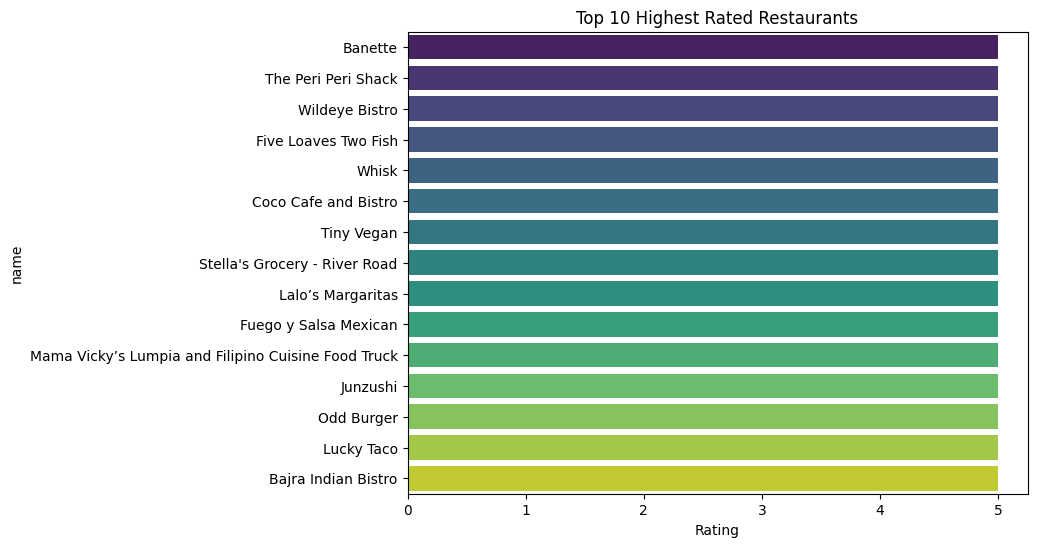

In [ ]:
# Top-rated restaurants
top_rated = restaurants_data.sort_values('rating', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x='rating', y='name', data=top_rated, palette='viridis')
plt.title('Top 10 Highest Rated Restaurants')
plt.xlabel('Rating')
plt.show()

<ipython-input-135-e0b15d6dbcd9>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Cuisine', data=top_cuisines, palette='coolwarm')


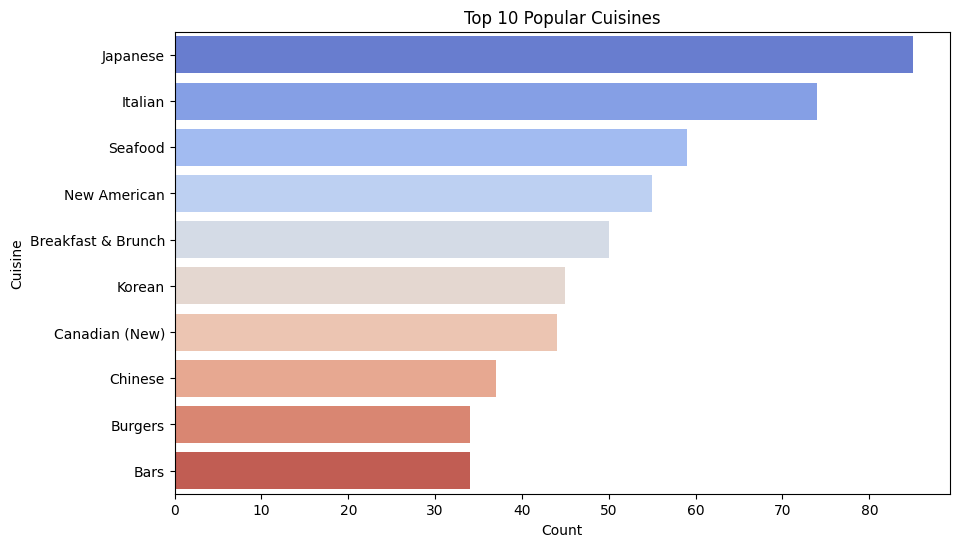

In [ ]:

from collections import Counter

# Count top cuisines
cuisine_list = ', '.join(restaurants_data['cuisine'].dropna()).split(', ')
top_cuisines = pd.DataFrame(Counter(cuisine_list).most_common(10), columns=['Cuisine', 'Count'])

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Cuisine', data=top_cuisines, palette='coolwarm')
plt.title('Top 10 Popular Cuisines')
plt.show()



Step 5: Data Transformation and Feature Engineering

Average Rating by Cuisine

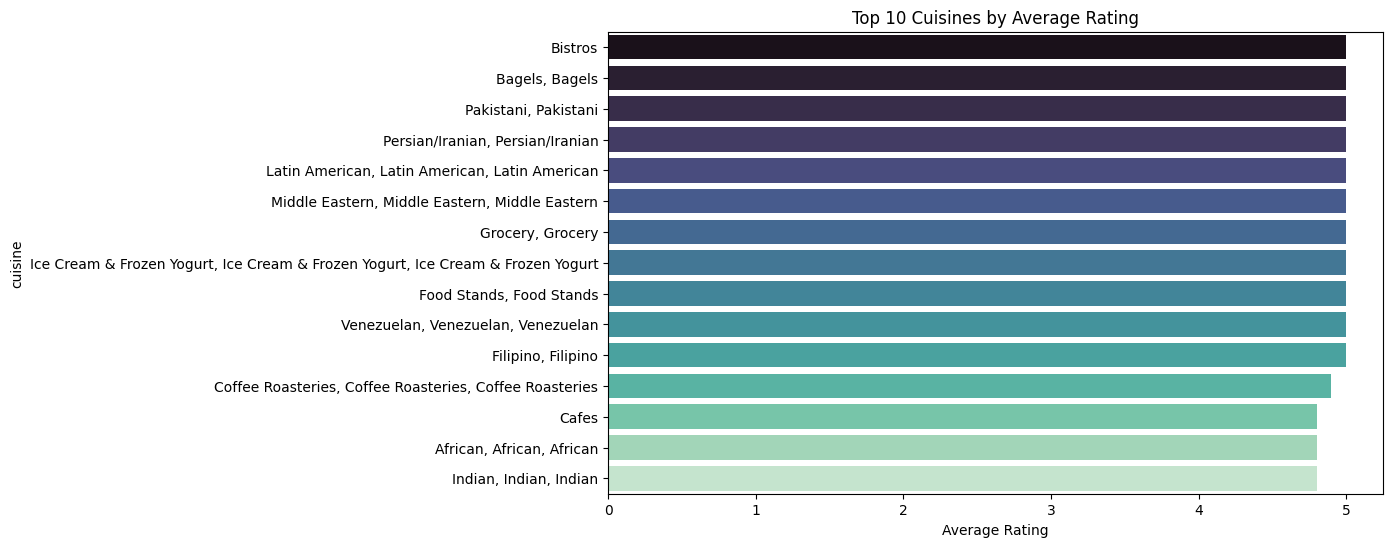

In [ ]:
avg_rating_by_cuisine = restaurants_data.groupby('cuisine')['rating'].mean().reset_index()
top_avg_cuisine = avg_rating_by_cuisine.sort_values('rating', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y='cuisine', data=top_avg_cuisine, palette='mako', hue='cuisine')
plt.title('Top 10 Cuisines by Average Rating')
plt.xlabel('Average Rating')
plt.show()

# service options by locations

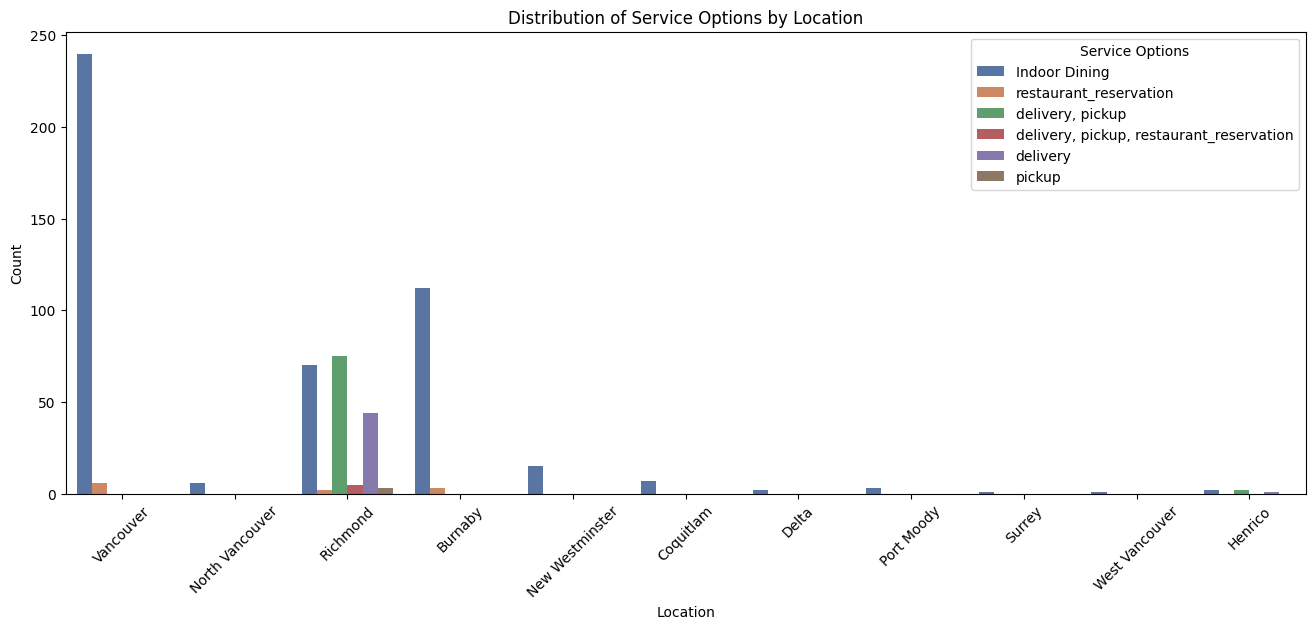

In [ ]:

# Visualize Service Options by Location
plt.figure(figsize=(16, 6))
sns.countplot(x='city', hue='service_options', data=restaurants_data, palette='deep')

# Customization
plt.title('Distribution of Service Options by Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Service Options')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report


In [ ]:
# Data Preparation

# Data Preparation
restaurants_data['service_count'] = restaurants_data['service_options'].str.split(', ').apply(len)
# Encoding Categorical Variables
restaurants_data = pd.get_dummies(restaurants_data, columns=['cuisine', 'service_options'], drop_first=True)


In [ ]:
# Creating Binary Target for Logistic Regression
restaurants_data['high_rating'] = (restaurants_data['rating'] >= 4.0).astype(int)

# Splitting Data
X = restaurants_data.drop(['rating', 'high_rating', 'name', 'address', 'city', 'state', 'zip'], axis=1)
y_linear = restaurants_data['rating']          # Linear Regression
y_logistic = restaurants_data['high_rating']   # Logistic Regression

In [ ]:
# split the data into train and test data.
X_train, X_test, y_train_lin, y_test_lin = train_test_split(X, y_linear, test_size=0.3, random_state=42)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.3, random_state=42)


In [ ]:
# ==================== SMOTE SAMPLING ====================
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train_log)

In [ ]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train_lin)
y_pred_lin = lin_reg.predict(X_test)
print(f"Linear Regression R² Score: {r2_score(y_test_lin, y_pred_lin):.2f}")


Linear Regression R² Score: -0.46


In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_resampled, y_resampled)
y_pred_log = log_reg.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_log, y_pred_log):.2f}")
print(classification_report(y_test_log, y_pred_log))

Logistic Regression Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.18      0.12      0.14        25
           1       0.87      0.91      0.89       155

    accuracy                           0.80       180
   macro avg       0.52      0.51      0.51       180
weighted avg       0.77      0.80      0.78       180



Accuracy: 0.66
➡️ This means 66% of total predictions were correct. While this is better than random guessing, it’s still far from optimal.

## Key Observations  
Class 0 (Negative)  
Precision = 0.13 → Out of all predicted negatives, only 13% were correct.  
Recall = 0.30 → Out of actual negatives, only 30% were correctly identified.  
F1-Score = 0.18 → The model struggles to balance precision and recall for Class 0.  

➡️ Class 0 detection remains weak.   

Class 1 (Positive)  
Precision = 0.87 → Out of all predicted positives, 87% were correct.  
Recall = 0.71 → Out of all actual positives, 71% were correctly identified.  
F1-Score = 0.78 → This reflects a good balance between precision and recall for Class 1.  

➡️ Class 1 detection is significantly better.